In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# consumption_facility Data Set

In [2]:
consumption_facility_df=pd.read_excel("Dataset/consumption_facility.xlsx")
consumption_facility_df.head()

,Patient_ID,Region,Medicine_ID,DrugName,Daily_Consumption_Units,Out_of_Stock_Days,Wastage_Units,Bed_Days,Supplies_Used
0,P001,Indore,M07208F17,LIGNOCAINE HYDROCHLORIDE 2% INJ,0.5,0,0,2,"Gloves, IV"
1,P001,Indore,M09598F70,ADRENALINE INJ 1ML,2.0,0,0,2,"Gloves, IV"
2,P001,Indore,M359D09B5,LIQUID PARAFFIN 100ML,0.0,0,1,2,"Gloves, IV"
3,P001,Indore,M524E5E35,ESOMEPRAZOLE 40MG,0.5,0,0,2,"Gloves, IV"
4,P001,Indore,M589A5AA4,WATER FOR INJECTION 10ML SOLUTION,3.0,0,0,2,"Gloves, IV"


# Data cleaning

In [3]:
consumption_facility_df.isnull().sum()

Patient_ID                 0
Region                     0
Medicine_ID                0
DrugName                   0
Daily_Consumption_Units    0
Out_of_Stock_Days          0
Wastage_Units              0
Bed_Days                   0
Supplies_Used              0
dtype: int64

In [4]:
consumption_facility_df.dtypes

Patient_ID                  object
Region                      object
Medicine_ID                 object
DrugName                    object
Daily_Consumption_Units    float64
Out_of_Stock_Days            int64
Wastage_Units                int64
Bed_Days                     int64
Supplies_Used               object
dtype: object

In [5]:
consumption_facility_df.duplicated().sum()

np.int64(0)

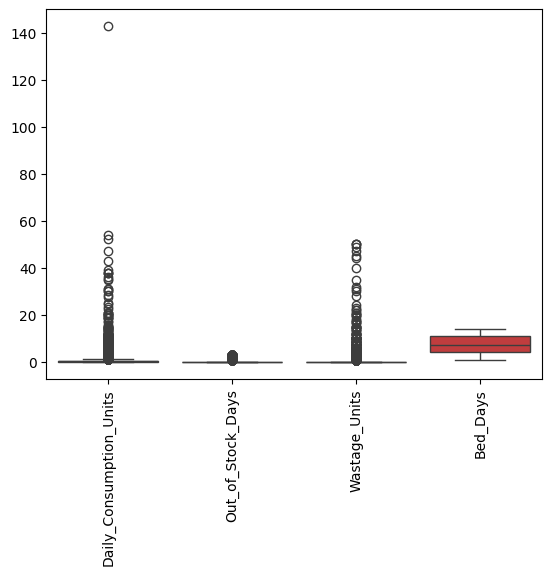

In [6]:
sns.boxplot(data=consumption_facility_df)
plt.xticks(rotation=90)
plt.show()

# Check outliers

# outliers treatments

num_cols = consumption_facility_df.select_dtypes(include=['int64', 'float64']).columns
num_cols = [col for col in num_cols if 'Flag' not in col]

# Step 1 — Detect outliers 
for col in num_cols:
    Q1 = consumption_facility_df[col].quantile(0.25)
    Q3 = consumption_facility_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_count = ((consumption_facility_df[col] < lower_bound) | 
                     (consumption_facility_df[col] > upper_bound)).sum()
    print(f"{col}: {outlier_count} outliers → will be capped")

# Step 2 — Clip only 
for col in num_cols:
    Q1 = consumption_facility_df[col].quantile(0.25)
    Q3 = consumption_facility_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    consumption_facility_df[col] = consumption_facility_df[col].clip(lower_bound, upper_bound)

# Step 3 — Confirm no more outliers
print(f"\nRows after treatment: {len(consumption_facility_df)}")
sns.boxplot(data=consumption_facility_df[num_cols])
plt.xticks(rotation=90)
plt.show()

# Feature Engineering

In [7]:
consumption_facility_df['Total_Consumption'] = (consumption_facility_df['Daily_Consumption_Units'] * consumption_facility_df['Bed_Days'])
consumption_facility_df['Total_Consumption']

0        1.0
1        4.0
2        0.0
3        1.0
4        6.0
        ... 
11106    5.5
11107    1.1
11108    2.2
11109    3.3
11110    1.1
Name: Total_Consumption, Length: 11111, dtype: float64

In [8]:
consumption_facility_df['Stockout_Flag'] = consumption_facility_df['Out_of_Stock_Days'] > 0
consumption_facility_df['Stockout_Flag'].value_counts()

Stockout_Flag
False    10795
True       316
Name: count, dtype: int64

In [9]:
consumption_facility_df['Stockout_Flag'] = consumption_facility_df['Stockout_Flag'].astype("category")
consumption_facility_df['Stockout_Flag']

0        False
1        False
2        False
3        False
4        False
         ...  
11106    False
11107    False
11108    False
11109    False
11110    False
Name: Stockout_Flag, Length: 11111, dtype: category
Categories (2, bool): [False, True]

In [10]:
consumption_facility_df['Wastage_Flag'] = consumption_facility_df['Wastage_Units'] > 0
consumption_facility_df['Wastage_Flag']


0        False
1        False
2         True
3        False
4        False
         ...  
11106    False
11107    False
11108    False
11109    False
11110    False
Name: Wastage_Flag, Length: 11111, dtype: bool

In [11]:
consumption_facility_df['Wastage_Flag'] = consumption_facility_df['Wastage_Flag'].astype("category")

In [12]:
consumption_facility_df['Consumption_per_Bed'] = (consumption_facility_df['Total_Consumption'] / consumption_facility_df['Bed_Days'])
consumption_facility_df['Consumption_per_Bed']

0        0.5
1        2.0
2        0.0
3        0.5
4        3.0
        ... 
11106    0.5
11107    0.1
11108    0.2
11109    0.3
11110    0.1
Name: Consumption_per_Bed, Length: 11111, dtype: float64

In [13]:
# Negative values
(consumption_facility_df['Daily_Consumption_Units'] < 0).sum()
# Bed days = 0?
(consumption_facility_df['Bed_Days'] == 0).sum()

np.int64(0)

In [14]:
consumption_facility_df.groupby('DrugName')['Total_Consumption'].sum().sort_values(ascending=False)

DrugName
                             8263.7
SODIUM CHLORIDE IVF 100ML    1288.4
SEVOFLURANE 99.97%           1193.2
SODIUM CHLORIDE 0.9%          955.5
ONDANSETRON 2MG/ML            934.8
                              ...  
METOPROLOL 50MG TAB             0.0
MEROPENEM 250MG INJ             0.0
ATENOLOL 25MG                   0.0
TORASEMIDE 20MG                 0.0
TORASEMIDE 40MG TAB             0.0
Name: Total_Consumption, Length: 752, dtype: float64

# Demand_sales Data Set

In [15]:
Demand_sales_df=pd.read_excel("Dataset/demand_sales.xlsx")
Demand_sales_df.head()

,Order_ID,Order_Date,Patient_ID,Dept,Specialisation,Medicine_ID,DrugName,Formulation,Quantity,ReturnQuantity,Final_Cost,Final_Sales,RtnMRP,Order_Status,Delivery_Date,Lead_Time_Days
0,O00001,2024-06-01,P045,Department1,Specialisation6,M1CA76D1B,ZINC ACETATE 20MG/5ML SYP,Form1,1,0,55.41,59.26,0.0,Cancelled,NaT,0
1,O00002,2024-09-18,P387,Department1,Specialisation7,M318FBCBC,CEFTAZIDIME 2GM+AVIBACTAM 500MG,Form1,1,0,768.64,950.80,0.0,Delivered,2024-09-27,9
2,O00003,2024-11-03,P328,Department3,Specialisation2,M82D7852E,EPTIFIBATIDE 0.75MG/ML,Form2,1,0,774.27,4004.21,0.0,Delivered,2024-11-06,3
3,O00004,2024-01-15,P220,Department1,Specialisation40,MCA6D8773,WATER FOR INJECTION 10ML SOLUTION,Form1,2,0,40.80,81.04,0.0,Cancelled,NaT,0
4,O00005,2024-09-27,P217,Department1,Specialisation5,M18E1DD4A,LORAZEPAM 1MG,Form1,1,0,40.43,40.50,0.0,Delivered,2024-10-09,12


In [16]:
Demand_sales_df["ReturnQuantity"].value_counts()

ReturnQuantity
0     12537
1       901
2       404
3       161
4        70
5        50
6        18
10       14
7         7
12        7
9         6
15        6
20        4
17        3
14        3
50        3
8         3
18        3
30        2
22        2
21        2
42        1
48        1
40        1
23        1
16        1
11        1
44        1
19        1
13        1
45        1
24        1
32        1
Name: count, dtype: int64

# Data cleaning

In [17]:
Demand_sales_df.dtypes

Order_ID                  object
Order_Date        datetime64[ns]
Patient_ID                object
Dept                      object
Specialisation            object
Medicine_ID               object
DrugName                  object
Formulation               object
Quantity                   int64
ReturnQuantity             int64
Final_Cost               float64
Final_Sales              float64
RtnMRP                   float64
Order_Status              object
Delivery_Date     datetime64[ns]
Lead_Time_Days             int64
dtype: object

In [18]:
Demand_sales_df.duplicated().sum()

np.int64(0)

In [19]:
Demand_sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14218 entries, 0 to 14217
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order_ID        14218 non-null  object        
 1   Order_Date      14218 non-null  datetime64[ns]
 2   Patient_ID      14218 non-null  object        
 3   Dept            14218 non-null  object        
 4   Specialisation  14218 non-null  object        
 5   Medicine_ID     14218 non-null  object        
 6   DrugName        14218 non-null  object        
 7   Formulation     14218 non-null  object        
 8   Quantity        14218 non-null  int64         
 9   ReturnQuantity  14218 non-null  int64         
 10  Final_Cost      14218 non-null  float64       
 11  Final_Sales     14218 non-null  float64       
 12  RtnMRP          14218 non-null  float64       
 13  Order_Status    14218 non-null  object        
 14  Delivery_Date   13585 non-null  datetime64[ns]
 15  Le

In [20]:
Demand_sales_df.isnull().sum()

Order_ID            0
Order_Date          0
Patient_ID          0
Dept                0
Specialisation      0
Medicine_ID         0
DrugName            0
Formulation         0
Quantity            0
ReturnQuantity      0
Final_Cost          0
Final_Sales         0
RtnMRP              0
Order_Status        0
Delivery_Date     633
Lead_Time_Days      0
dtype: int64

In [21]:
Demand_sales_df['Order_Status'].value_counts()

Order_Status
Delivered    11310
Returned      1681
Cancelled      633
Pending        594
Name: count, dtype: int64

In [22]:
Demand_sales_df['Order_Status'] = Demand_sales_df['Order_Status'].astype('category')

In [23]:
Demand_sales_df[Demand_sales_df['Delivery_Date'].isnull()]['Order_Status'].value_counts()

Order_Status
Cancelled    633
Delivered      0
Pending        0
Returned       0
Name: count, dtype: int64

# All those orders which were cancelled has null delivery date. we wont treat it as missing values nor we will remove it as its important for further analysis.


# Check outliers

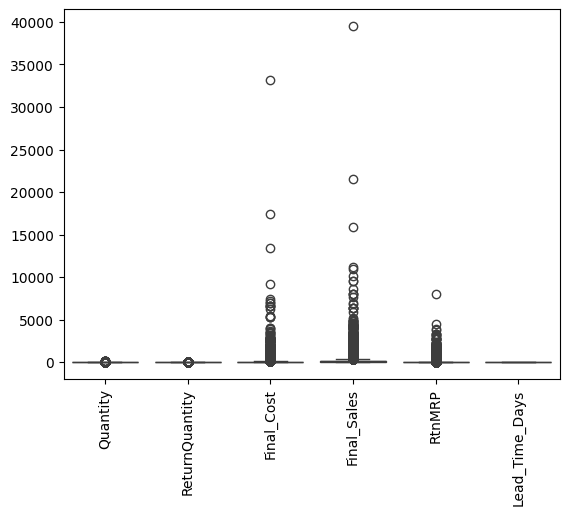

In [24]:
sns.boxplot(data=Demand_sales_df)
plt.xticks(rotation=90)
plt.show()

# outliers treatments

cols_to_treat = [
    'Final_Sales', 
    'Final_Cost', 
    'RtnMRP', 
    'Quantity',
    'ReturnQuantity'
]

for col in cols_to_treat:
    Q1 = Demand_sales_df[col].quantile(0.25)
    Q3 = Demand_sales_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    Demand_sales_df[col] = Demand_sales_df[col].clip(lower_bound, upper_bound)

sns.boxplot(data=Demand_sales_df)
plt.xticks(rotation=90)
plt.show()

# Feature Engineering

In [25]:
Demand_sales_df['Delivered_Flag'] = (Demand_sales_df['Order_Status'] == 'Delivered')
Demand_sales_df['Delivered_Flag']

0        False
1         True
2         True
3        False
4         True
         ...  
14213     True
14214     True
14215     True
14216     True
14217     True
Name: Delivered_Flag, Length: 14218, dtype: bool

In [26]:
Demand_sales_df['Delivery_Delay'] = np.where(Demand_sales_df['Order_Status'] == 'Delivered',
                                             (Demand_sales_df['Delivery_Date'] - Demand_sales_df['Order_Date']).dt.days,np.nan)
Demand_sales_df['Delivery_Delay']

0         NaN
1         9.0
2         3.0
3         NaN
4        12.0
         ... 
14213     7.0
14214     5.0
14215     7.0
14216     9.0
14217     6.0
Name: Delivery_Delay, Length: 14218, dtype: float64

In [27]:
Demand_sales_df['Return_Percentage'] = Demand_sales_df.apply(
    lambda r: (r['ReturnQuantity'] / r['Quantity']) * 100
    if r['Quantity'] > 0 else np.nan, axis=1
)
print(Demand_sales_df['Return_Percentage'].describe())
print("Non-zero values:", (Demand_sales_df['Return_Percentage'] > 0).sum())


count    12537.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: Return_Percentage, dtype: float64
Non-zero values: 0


In [28]:
Demand_sales_df['Profit'] = (Demand_sales_df['Final_Sales'] - Demand_sales_df['Final_Cost'])
Demand_sales_df['Profit']

0           3.85
1         182.16
2        3229.94
3          40.24
4           0.07
          ...   
14213      83.76
14214      55.24
14215     567.10
14216      69.32
14217      87.62
Name: Profit, Length: 14218, dtype: float64

In [29]:
Demand_sales_df['Order_Month'] = Demand_sales_df['Order_Date'].dt.to_period('M')
Demand_sales_df['Order_Month']

0        2024-06
1        2024-09
2        2024-11
3        2024-01
4        2024-09
          ...   
14213    2024-06
14214    2024-09
14215    2024-09
14216    2024-12
14217    2024-08
Name: Order_Month, Length: 14218, dtype: period[M]

In [30]:
# Negative values
(Demand_sales_df['Quantity'] < 0).sum()

np.int64(0)

In [31]:
(Demand_sales_df['Delivery_Date'] < Demand_sales_df['Order_Date']).sum()

np.int64(0)

In [32]:
(Demand_sales_df['Lead_Time_Days'] != Demand_sales_df['Delivery_Delay']).sum()

np.int64(3101)

In [33]:
delivered_df = Demand_sales_df[Demand_sales_df['Order_Status'] == 'Delivered']

In [34]:
(delivered_df['Lead_Time_Days'] != delivered_df['Delivery_Delay']).sum()

np.int64(193)

In [35]:
Demand_sales_df['Lead_Time_Final'] = Demand_sales_df['Lead_Time_Days']
Demand_sales_df['Lead_Time_Final']

0         0
1         9
2         3
3         0
4        12
         ..
14213     7
14214     5
14215     7
14216     9
14217     6
Name: Lead_Time_Final, Length: 14218, dtype: int64

# Inventory Data Set

In [36]:
inventory_stock_df=pd.read_excel("Dataset/inventory_stock.xlsx")
inventory_stock_df.head()

,Medicine_ID,DrugName,Formulation,Category,Batch_No,Manufacture_Date,Expiry_Date,Current_Stock,Min_Required,Max_Capacity,Unit_Cost,Avg_Usage_Per_Day,Restock_Lead_Time_Days,Reorder_Level,Stock_Cover_Days,Vendor_ID
0,M07208F17,LIGNOCAINE HYDROCHLORIDE 2% INJ,Injection,Parenteral,BATCH1803,2023-02-21,2024-02-21,230,32,845,127.10,3,6,35,77,V923
1,M09598F70,ADRENALINE INJ 1ML,Injection,Parenteral,BATCH7964,2023-08-12,2024-08-11,78,79,925,182.88,6,7,87,13,V775
2,M359D09B5,LIQUID PARAFFIN 100ML,Other,Other,BATCH6890,2023-06-24,2025-06-23,195,69,949,34.44,14,9,76,14,V307
3,M524E5E35,ESOMEPRAZOLE 40MG,Other,Other,BATCH4949,2023-02-19,2025-02-18,260,43,381,183.12,7,3,47,37,V270
4,M589A5AA4,WATER FOR INJECTION 10ML SOLUTION,Injection,Parenteral,BATCH4896,2023-03-03,2024-03-02,476,53,685,180.99,12,9,58,40,V711


In [37]:
# Reference date = Start of your order period
inventory_stock_df['Expiry_Risk'] = (
    inventory_stock_df['Expiry_Date'] < pd.to_datetime('2024-12-31')
)

print(inventory_stock_df['Expiry_Risk'].value_counts())

Expiry_Risk
False    674
True     167
Name: count, dtype: int64


# Data cleaning

In [38]:
inventory_stock_df.dtypes

Medicine_ID                       object
DrugName                          object
Formulation                       object
Category                          object
Batch_No                          object
Manufacture_Date          datetime64[ns]
Expiry_Date               datetime64[ns]
Current_Stock                      int64
Min_Required                       int64
Max_Capacity                       int64
Unit_Cost                        float64
Avg_Usage_Per_Day                  int64
Restock_Lead_Time_Days             int64
Reorder_Level                      int64
Stock_Cover_Days                   int64
Vendor_ID                         object
Expiry_Risk                         bool
dtype: object

In [39]:
inventory_stock_df['Category'] = inventory_stock_df['Category'].astype('category')
inventory_stock_df['Formulation'] = inventory_stock_df['Formulation'].astype('category')

In [40]:
inventory_stock_df.duplicated().sum()

np.int64(0)

In [41]:
inventory_stock_df.isnull().sum()

Medicine_ID               0
DrugName                  0
Formulation               0
Category                  0
Batch_No                  0
Manufacture_Date          0
Expiry_Date               0
Current_Stock             0
Min_Required              0
Max_Capacity              0
Unit_Cost                 0
Avg_Usage_Per_Day         0
Restock_Lead_Time_Days    0
Reorder_Level             0
Stock_Cover_Days          0
Vendor_ID                 0
Expiry_Risk               0
dtype: int64

# Check outliers

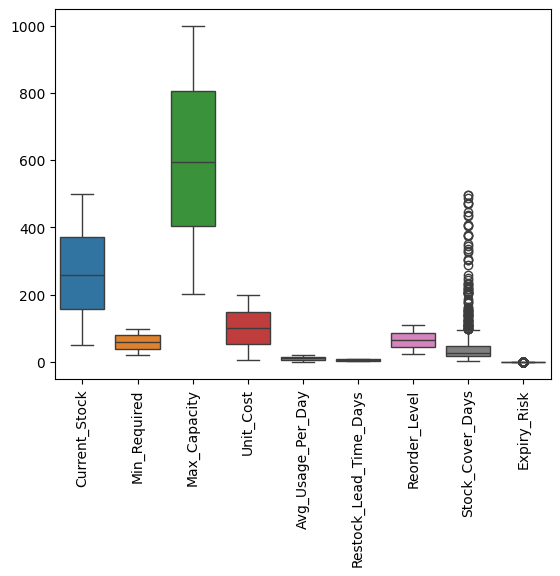

In [42]:
sns.boxplot(data=inventory_stock_df)
plt.xticks(rotation=90)
plt.show()

# outliers treatments

In [43]:
cols_to_treat = ['Stock_Cover_Days']

for col in cols_to_treat:
    Q1 = inventory_stock_df[col].quantile(0.25)
    Q3 = inventory_stock_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    inventory_stock_df[col] = inventory_stock_df[col].clip(lower_bound, upper_bound)

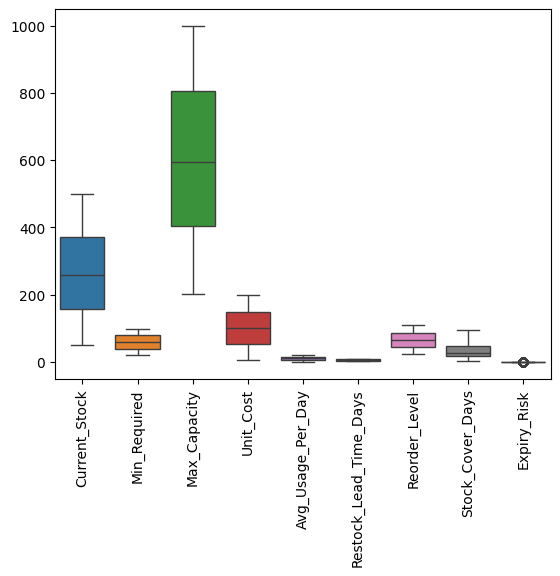

In [44]:
sns.boxplot(data=inventory_stock_df)
plt.xticks(rotation=90)
plt.show()

# Feature Engineering

In [45]:
inventory_stock_df['Inventory_Gap'] = (inventory_stock_df['Current_Stock'] - inventory_stock_df['Min_Required'])
inventory_stock_df['Inventory_Gap']

0      198
1       -1
2      126
3      217
4      423
      ... 
836    213
837    414
838    338
839     40
840    376
Name: Inventory_Gap, Length: 841, dtype: int64

In [46]:
inventory_stock_df['Stockout_Risk'] = (inventory_stock_df['Current_Stock'] < inventory_stock_df['Min_Required'])
inventory_stock_df['Stockout_Risk']

0      False
1       True
2      False
3      False
4      False
       ...  
836    False
837    False
838    False
839    False
840    False
Name: Stockout_Risk, Length: 841, dtype: bool

In [47]:
inventory_stock_df['Reorder_Flag'] = (inventory_stock_df['Current_Stock'] < inventory_stock_df['Reorder_Level'])
inventory_stock_df['Reorder_Flag']

0      False
1       True
2      False
3      False
4      False
       ...  
836    False
837    False
838    False
839    False
840    False
Name: Reorder_Flag, Length: 841, dtype: bool

In [48]:
inventory_stock_df['Overstock_Flag'] = (inventory_stock_df['Current_Stock'] > inventory_stock_df['Max_Capacity'] * 0.8)
inventory_stock_df['Overstock_Flag']

0      False
1      False
2      False
3      False
4      False
       ...  
836     True
837     True
838    False
839    False
840     True
Name: Overstock_Flag, Length: 841, dtype: bool

In [49]:
inventory_stock_df['Expiry_Risk'] = (inventory_stock_df['Expiry_Date'] < pd.to_datetime('2025-01-01'))
inventory_stock_df['Expiry_Risk']

0       True
1       True
2      False
3      False
4       True
       ...  
836    False
837    False
838    False
839    False
840    False
Name: Expiry_Risk, Length: 841, dtype: bool

In [50]:
inventory_stock_df['Stock_per_Day'] = (inventory_stock_df['Current_Stock'] / inventory_stock_df['Avg_Usage_Per_Day'])
inventory_stock_df['Stock_per_Day']

0      76.666667
1      13.000000
2      13.928571
3      37.142857
4      39.666667
         ...    
836    47.833333
837    27.388889
838    48.125000
839    14.000000
840    59.857143
Name: Stock_per_Day, Length: 841, dtype: float64

In [51]:
(inventory_stock_df['Current_Stock'] < 0).sum()

np.int64(0)

In [52]:
(inventory_stock_df['Min_Required'] > inventory_stock_df['Max_Capacity']).sum()

np.int64(0)

In [53]:
(inventory_stock_df['Expiry_Date'] < inventory_stock_df['Manufacture_Date']).sum()

np.int64(0)

# suply procurements data set

In [54]:
supplier_procurement_df=pd.read_excel("Dataset/supplier_procurement.xlsx")
supplier_procurement_df.head()

,Supplier_ID,Supplier_Name,Region,Avg_Lead_Time_Days,Reliability_Score,Cost_Per_Item,Last_Order_Date,Next_Delivery_Date,On_Time_Delivery_Rate
0,V923,Supplier_1,Delhi,12,4.2,116.21,2024-01-19,2024-01-31,75
1,V775,Supplier_2,Delhi,9,4.6,113.26,2024-11-14,2024-11-23,73
2,V307,Supplier_3,Pune,8,4.1,118.98,2024-09-18,2024-09-26,80
3,V270,Supplier_4,Pune,9,3.8,103.85,2024-05-24,2024-06-02,71
4,V711,Supplier_5,Pune,12,4.4,112.12,2024-08-10,2024-08-22,71


# Data cleaning

In [55]:
supplier_procurement_df.dtypes

Supplier_ID                      object
Supplier_Name                    object
Region                           object
Avg_Lead_Time_Days                int64
Reliability_Score               float64
Cost_Per_Item                   float64
Last_Order_Date          datetime64[ns]
Next_Delivery_Date       datetime64[ns]
On_Time_Delivery_Rate             int64
dtype: object

In [56]:
supplier_procurement_df['Region'] = supplier_procurement_df['Region'].astype('category')

In [57]:
supplier_procurement_df.duplicated().sum()

np.int64(0)

In [58]:
supplier_procurement_df.isnull().sum()

Supplier_ID              0
Supplier_Name            0
Region                   0
Avg_Lead_Time_Days       0
Reliability_Score        0
Cost_Per_Item            0
Last_Order_Date          0
Next_Delivery_Date       0
On_Time_Delivery_Rate    0
dtype: int64

# Check outliers

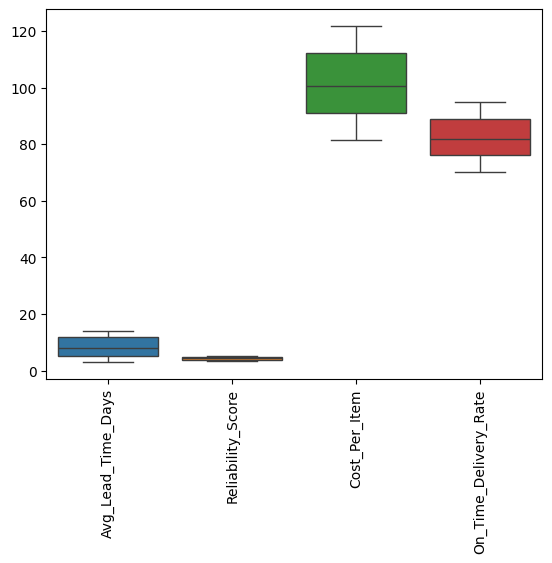

In [59]:
sns.boxplot(data=supplier_procurement_df)
plt.xticks(rotation=90)
plt.show()

# Feature Engineering

In [60]:
supplier_procurement_df['Delay_Risk'] = (supplier_procurement_df['Avg_Lead_Time_Days'] > 10)
supplier_procurement_df['Delay_Risk']

0       True
1      False
2      False
3      False
4       True
       ...  
533    False
534     True
535     True
536    False
537     True
Name: Delay_Risk, Length: 538, dtype: bool

In [61]:
supplier_procurement_df['Reliability_Level'] = np.where(supplier_procurement_df['Reliability_Score'] >= 4,'High','Low')
supplier_procurement_df['Reliability_Level']

0      High
1      High
2      High
3       Low
4      High
       ... 
533    High
534    High
535    High
536    High
537     Low
Name: Reliability_Level, Length: 538, dtype: object

In [62]:
supplier_procurement_df['Poor_Performance'] = (supplier_procurement_df['On_Time_Delivery_Rate'] < 75)
supplier_procurement_df['Poor_Performance']

0      False
1       True
2      False
3       True
4       True
       ...  
533    False
534    False
535    False
536    False
537     True
Name: Poor_Performance, Length: 538, dtype: bool

In [63]:
supplier_procurement_df['Efficiency_Score'] = (supplier_procurement_df['On_Time_Delivery_Rate'] / supplier_procurement_df['Avg_Lead_Time_Days'])
supplier_procurement_df['Efficiency_Score']

0       6.250000
1       8.111111
2      10.000000
3       7.888889
4       5.916667
         ...    
533    12.714286
534     6.846154
535     7.307692
536    10.000000
537     5.214286
Name: Efficiency_Score, Length: 538, dtype: float64

In [64]:
supplier_procurement_df['Delivery_Gap_Days'] = (supplier_procurement_df['Next_Delivery_Date'] - supplier_procurement_df['Last_Order_Date']).dt.days
supplier_procurement_df['Delivery_Gap_Days']

0      12
1       9
2       8
3       9
4      12
       ..
533     7
534    13
535    13
536     8
537    14
Name: Delivery_Gap_Days, Length: 538, dtype: int64

In [65]:
# Check negative values
(supplier_procurement_df['Avg_Lead_Time_Days'] < 0).sum()

np.int64(0)

In [66]:
# Check delivery rate range
(supplier_procurement_df['On_Time_Delivery_Rate'] > 100).sum()

np.int64(0)

In [67]:
consumption_facility_df.to_csv("dataset/consumption_facility_cleaned.csv", index=False)
Demand_sales_df.to_csv("dataset/demand_sales_cleaned.csv", index=False)
inventory_stock_df.to_csv("dataset/inventory_stock_cleaned.csv", index=False)
supplier_procurement_df.to_csv("dataset/supplier_procurement_cleaned.csv", index=False)